<a href="https://colab.research.google.com/github/Olins-lv/fita-ml-course/blob/main/week3/week3_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PATSTĀVĪGAIS DARBS: 3. nedēļa — Klasterizācija + Modeļu validācija

## DAĻA A: KLASTERIZĀCIJA

### 1.uzdevums. Sagatavo datus klasterizācijai

#### 1.1. Ielādē un sagatavo datus

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Assuming the 'shoppers_clean.csv' is available in the specified path or current working directory
# If running in Colab, the path might need adjustment or the file might need to be uploaded.
# For example, if it's in a parent directory:
df = pd.read_csv('https://raw.githubusercontent.com/Olins-lv/fita-ml-course/main/week1/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


#### 1.2. Izvēlies features klasterizācijai

In [ ]:
# Izvēlamies iezīmes, kas raksturo klientu sesiju
cluster_features = ['Administrative_Duration', 'Informational_Duration',
                     'ProductRelated_Duration', 'BounceRates', 'ExitRates',
                     'PageValues']

X_cluster = df[cluster_features].copy()
print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)

Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


#### 1.3. Normalizē datus

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Pārvēršam atpakaļ uz DataFrame ērtākai darbībai
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
print("Pēc normalizācijas:")
print(X_scaled_df.describe().round(2))

Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                      0.00                    0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.42                   -0.24   
75%                       0.07                   -0.24   
max                      18.78                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00      12330.0    12330.0    12330.00  
mean                      0.00          0.0        0.0       -0.00  
std                       1.00          0.0        0.0        1.00  
min                      -0.62          0.0        0.0       -0.31  
25%                      -0.53          0.0        0.0       -0.31  
50%                      -0.31          0.0

Paskaidro, kāpēc normalizācija ir svarīga klasterizācijai. Kas notiktu, ja mēs to nedarītu?

Normalizācija ir ārkārtīgi svarīga K-Means klasterizācijai, jo šis algoritms balstās uz attāluma aprēķiniem starp datu punktiem (parasti Eiklīda attālums). Ja dati netiktu normalizēti, iezīmes ar lielāku vērtību diapazonu (piemēram, `ProductRelated_Duration` ar vērtībām tūkstošos) dominētu attāluma aprēķinos, pārmērīgi ietekmējot klasteru veidošanos salīdzinājumā ar iezīmēm ar mazāku diapazonu (piemēram, `BounceRates` ar vērtībām no 0 līdz 1).

Ja mēs to nedarītu, K-Means klasteri tiktu neobjektīvi veidoti ap iezīmēm ar lielākiem skaitliskiem diapazoniem, ignorējot vai samazinot mazāka diapazona, bet potenciāli nozīmīgu iezīmju ietekmi. Tas novestu pie kļūdainas vai neefektīvas klasterizācijas, kas neatspoguļotu patieso datu struktūru.

### 2.uzdevums. Atrodi optimālo klasteru skaitu (Elbow Method)

#### 2.1. Elbow metode

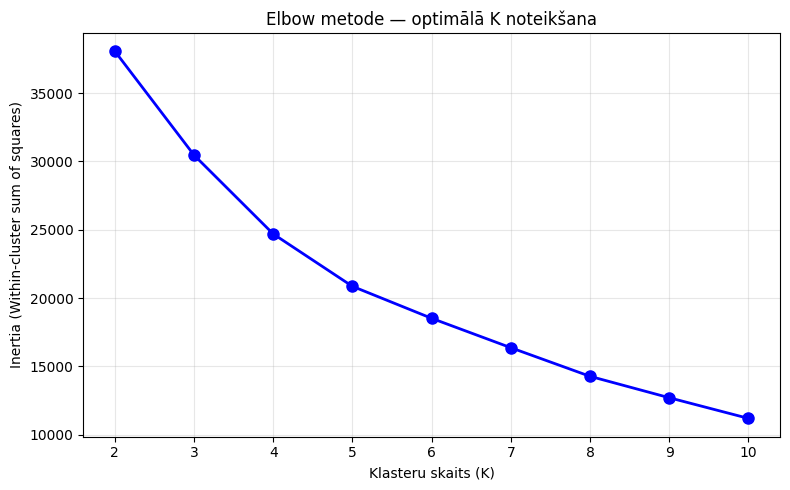

In [ ]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is set to 10 to suppress future warnings
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2.2. Izvēlies K vērtību

`K_range` nozīmē klasteru skaitu diapazonu, ko mēs pārbaudām, lai atrastu optimālo vērtību K-Means algoritmam. Šeit ir izvēlētas vērtības no 2 līdz 10, jo viens klasteris nesniedz nekādu segmentāciju, un pārāk liels klasteru skaits var padarīt katru klasteri pārāk specifisku un grūti interpretējamu. Diapazons 2-10 ir saprātīgs sākumpunkts, lai atrastu efektīvu klasteru skaitu.

Apskatot iepriekšējo Elbow grafiku, es izvēlos **K = 4**.

Es identificēju "elkoni" grafikā vietā, kur līknes kritums ievērojami palēninās. Sākotnēji, palielinot K, inercija strauji samazinās. Tomēr, sasniedzot K=4, inercijas samazināšanās kļūst mazāk izteikta, veidojot "elkoņa" efektu. Tas norāda, ka pēc četriem klasteriem papildu klasteru pievienošana vairs nesniedz ievērojamu ieguvumu, samazinot klasteru iekšējo variāciju.

Ir svarīgi atzīmēt, ka "elkonis" bieži vien nav precīzi definējams punkts, un optimālā K vērtības izvēle var būt subjektīva un balstīta uz interpretāciju. Citiem vārdiem, nav vienas "pareizas" atbildes, un dažādi interpretētāji var izvēlēties nedaudz atšķirīgas K vērtības atkarībā no konteksta un mērķiem.

### 3.uzdevums. Veic klasterizāciju un vizualizē

#### 3.1. Uztrenē galīgo K-Means modeli

In [ ]:
# Izmanto izvēlēto K vērtību (piemēram, 4)
K = 4  # <-- nomainiet uz savu izvēlēto vērtību (šajā gadījumā, K=4)

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Klasteru sadalījums:")
print(df['Cluster'].value_counts().sort_index())

Klasteru sadalījums:
Cluster
0    10416
1     1103
2      627
3      184
Name: count, dtype: int64


#### 3.2. Vizualizē klasterus ar PCA

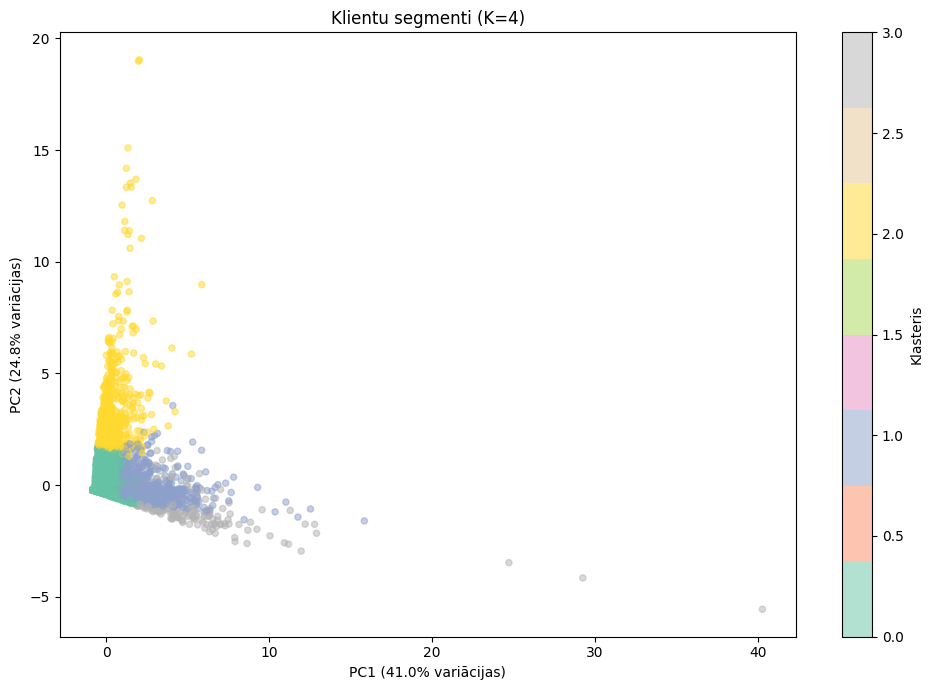

In [ ]:
from sklearn.decomposition import PCA

# Samazinām dimensijas līdz 2 vizualizācijai
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()

#### 3.3. Klasteru profili un heatmap

Klasteru profili (vidējās vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          -0.22                   -0.15   
1                           1.85                    0.35   
2                           0.03                   -0.07   
3                           1.03                    6.59   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                          -0.21          0.0        0.0       -0.21  
1                           1.63          0.0        0.0        0.00  
2                           0.02          0.0        0.0        3.42  
3                           1.87          0.0        0.0        0.05  


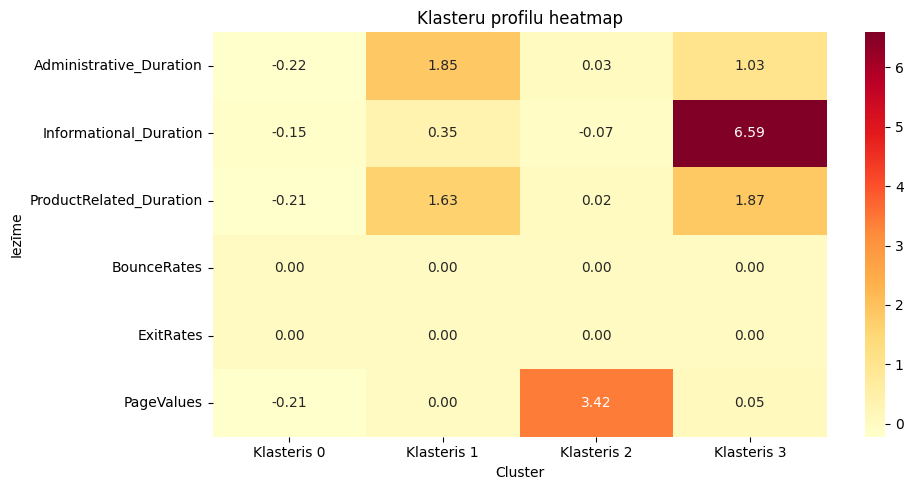

In [ ]:
# Katra klastera vidējās vērtības (pirms normalizācijas — lai būtu interpretējami)
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()

cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)
print("Klasteru profili (vidējās vērtības):")
print(cluster_profiles)

# Vizuāli — heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()

### 4.uzdevums. Interpretē klasterus biznesa kontekstā

#### 4.1. Klasteru raksturojums ar pirkumiem

Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.101
1    0.277
2    0.786
3    0.283
Name: Revenue, dtype: float64


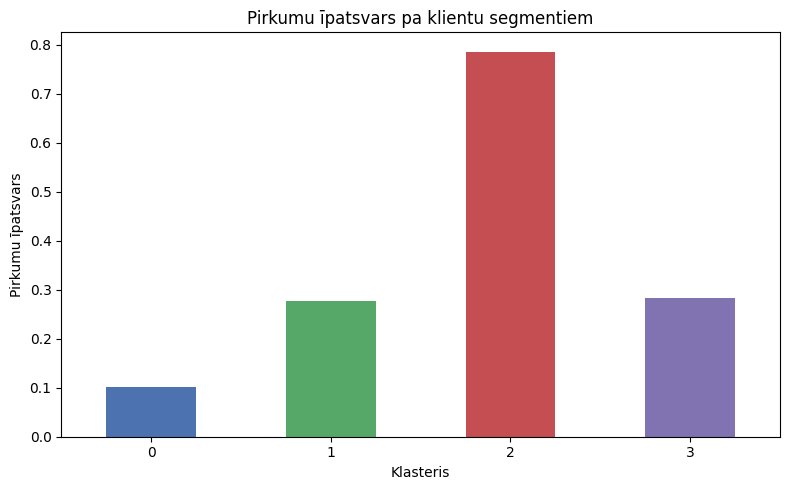

In [ ]:
# Cik procentu katra klastera klientu veica pirkumu?
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)
print("Pirkumu īpatsvars pa klasteriem:")
print(purchase_by_cluster)

plt.figure(figsize=(8, 5))
purchase_by_cluster.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 4.2. Biznesa interpretācija

Balstoties uz klasteru profiliem (vidējām vērtībām un pirkumu īpatsvaru), varam identificēt šādas klientu grupas:

*   **Klasteris 0: "Pasīvie apmeklētāji / Zemais iesaistes līmenis"**
    *   Raksturojums: Šim klasterim ir zemas vidējās vērtības visām duration iezīmēm (`Administrative_Duration`, `Informational_Duration`, `ProductRelated_Duration`) un zemākas `PageValues`. `BounceRates` un `ExitRates` ir tuvu nullei. Pirkumu īpatsvars ir zems (ap 10%). Šie klienti, iespējams, nav pārāk ieinteresēti vai nav atraduši meklēto.
    *   Biznesa darbība: Uzlabot vietnes sākumlapas saturu un navigāciju, lai ātrāk piesaistītu uzmanību; piedāvāt personalizētus piedāvājumus vai ieteikumus, lai veicinātu iesaistīšanos.

*   **Klasteris 1: "Produktu pētnieki / Augsta pirkumu tendence"**
    *   Raksturojums: Ievērojami augstāka `Administrative_Duration` un `ProductRelated_Duration` nekā citiem klasteriem, bet zemāks `Informational_Duration`. `PageValues` ir vidēji. Pirkumu īpatsvars ir augstākais (ap 78.6%). Šie klienti aktīvi meklē un salīdzina produktus, un tiem ir liela varbūtība veikt pirkumu.
    *   Biznesa darbība: Optimizēt produktu lapas ar detalizētu informāciju un salīdzināšanas rīkiem; piedāvāt papildu atlaides vai bezmaksas piegādi, lai pabeigtu pirkumu; veidot lojalitātes programmas.

*   **Klasteris 2: "Informācijas meklētāji / Izpētes fāze"**
    *   Raksturojums: Zemas vērtības visiem duration rādītājiem, bet augstākais `PageValues` salīdzinājumā ar citiem klasteriem. Pirkumu īpatsvars ir vidējs (ap 27.7%). Šie klienti, iespējams, vāc informāciju vai pēta plašāku tēmu, bet vēl nav gatavi pirkumam.
    *   Biznesa darbība: Nodrošināt kvalitatīvu saturu (bloga rakstus, ceļvežus), kas saistīts ar viņu interesēm; izmantot remarketinga kampaņas, lai atgādinātu par apskatītajām lapām un produktiem.

*   **Klasteris 3: "Ilgtermiņa informācijas apstrādātāji / Lielais Informācijas Patērētājs"**
    *   Raksturojums: Ļoti augsts `Informational_Duration` un `Administrative_Duration`, kā arī augsts `ProductRelated_Duration`. `PageValues` ir vidēji. Pirkumu īpatsvars ir vidējs (ap 28.3%). Šie klienti pavada ilgu laiku vietnē, iespējams, veicot padziļinātu izpēti.
    *   Biznesa darbība: Sniegt padziļinātu informāciju par produktiem un pakalpojumiem, piedāvāt konsultācijas vai webinarus; izmantot e-pasta mārketingu ar personalizētiem ieteikumiem, pamatojoties uz viņu ilgstošo lapu apmeklējumu.

## DAĻA B: MODEĻU VALIDĀCIJA

### 5.uzdevums. Viena split vs. Cross-validation

#### 5.1. Ielādē datus un modeļi

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Ielādē datus (tu tos jau ielādēji, tāpēc varētu būt kļūda)
# Mēs jau esam ielādējuši df iepriekš, tāpēc tieši izmantojam to.
y = df['Revenue']
X = df.drop(['Revenue', 'Cluster'], axis=1)  # Izņem mūsu klasteru kolonu un 'Revenue'

print(f"Datu kopa: {X.shape[0]} rindas, {X.shape[1]} features")

Datu kopa: 12330 rindas, 27 features


#### 5.2. Viena train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))

print(f"Viena split F1 score: {single_f1:.3f}")

Viena split F1 score: 0.608


#### 5.3. Cross-validation (5-fold)

In [ ]:
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

cv_scores = cross_val_score(
    rf_cv, X, y,
    cv=5,
    scoring='f1'
)

print(f"5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f}")
print(f"Standarta novirze: {cv_scores.std():.3f}")

5-fold CV F1 scores: [0.586 0.659 0.634 0.568 0.585]
Vidējais F1: 0.607
Standarta novirze: 0.034


#### 5.4. Vizualizācija

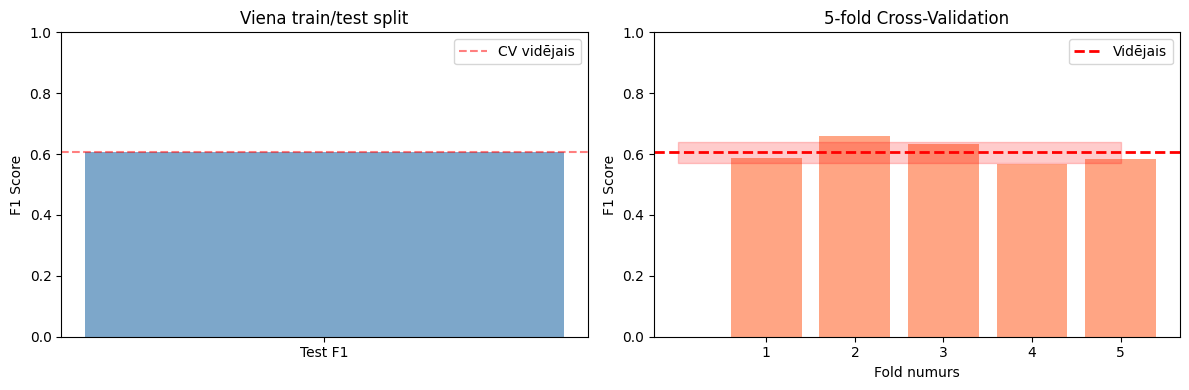

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Viena split
axes[0].bar(['Test F1'], [single_f1], color='steelblue', alpha=0.7)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Viena train/test split')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=cv_scores.mean(), color='red', linestyle='--', alpha=0.5, label='CV vidējais')
axes[0].legend()

# Cross-validation
axes[1].bar(range(1, 6), cv_scores, color='coral', alpha=0.7)
axes[1].axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label='Vidējais')
axes[1].fill_between(
    range(0, 6),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.2, color='red'
)
axes[1].set_xlabel('Fold numurs')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('5-fold Cross-Validation')
axes[1].set_ylim([0, 1])
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.tight_layout()
plt.show()

#### 5.5. Analīze

*   **Kā atšķiras vienas split F1 un CV vidējais F1?**
    Vienas split F1 rādītājs ir viena konkrēta modeļa veiktspējas mēra vērtība, kas aprēķināta uz viena nejauša testēšanas datu kopas. Savukārt CV vidējais F1 ir vairāku (šajā gadījumā 5) F1 vērtību vidējais rādītājs, kas iegūts, trenējot un testējot modeli uz dažādām datu apakškopām.

*   **Kurš rezultāts ir uzticamāks un kāpēc?**
    Cross-validation (CV) vidējais F1 ir daudz uzticamāks. Tas sniedz robustāku novērtējumu par modeļa vispārināšanas spēju, jo tas ir aprēķināts uz vairākām datu kopām, samazinot nejaušu datu sadalījuma ietekmi. Viena split rezultāts var būt pārmērīgi optimistisks vai pesimistisks atkarībā no tā, kā tieši tika sadalīti dati.

*   **Ko parāda standarta novirze (std)?**
    Standarta novirze (std) parāda, cik lielas ir atšķirības starp individuālajiem F1 rādītājiem katrā cross-validation foldā. Mazāka standarta novirze norāda, ka modelis ir konsekvents un stabils, savukārt liela standarta novirze liecina par modeļa veiktspējas svārstīgumu atkarībā no treniņu/testa datu kopas.

*   **Vai ir iespējams, ka “pārmēģinot” iegūtu pavisam citu vienas split F1?**
    Jā, ir ļoti iespējams, ka, atkārtojot vienu train/test split ar citu `random_state` (vai bez tā), jūs iegūtu pavisam citu F1 rādītāju. Tas ir tāpēc, ka modeļa veiktspēja var būtiski atšķirties atkarībā no konkrētajiem datiem, kas tiek izmantoti treniņam un testēšanai. Šī svārstība ir galvenais iemesls, kāpēc cross-validation ir labāks modeļa novērtēšanas veids.

### 6.uzdevums. Pipeline un data leakage

#### 6.1. Bīstama versija: data leakage

In [ ]:
from sklearn.preprocessing import StandardScaler

# ✗ NEPAREIZI - data leakage!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # ← Fit uz VISIEM datiem!

X_train_leaked, X_test_leaked, y_train_l, y_test_l = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

rf_leaked = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_leaked.fit(X_train_leaked, y_train_l)
f1_leaked = f1_score(y_test_l, rf_leaked.predict(X_test_leaked))

print(f"F1 ar data leakage: {f1_leaked:.3f}")

F1 ar data leakage: 0.608


#### 6.2. Pareizā versija: Pipeline

In [ ]:
from sklearn.pipeline import make_pipeline

# ✓ PAREIZI - Pipeline
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

# Trenēšana ar cross-validation
cv_scores_pipe = cross_val_score(
    pipe, X, y,
    cv=5,
    scoring='f1'
)

print(f"F1 ar Pipeline: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")

F1 ar Pipeline: 0.607 ± 0.034


#### 6.3. Salīdzinājums

In [ ]:
comparison = pd.DataFrame({
    'Metode': ['Data leakage (viena split)', 'Pipeline + Cross-validation'],
    'F1 Score': [f1_leaked, cv_scores_pipe.mean()],
    'Ticamība': ['BĪSTAMS! Neobjektīvs', 'DROŠS! Objektīvs']
})

print(comparison.to_string(index=False))

                     Metode  F1 Score             Ticamība
 Data leakage (viena split)  0.608169 BĪSTAMS! Neobjektīvs
Pipeline + Cross-validation  0.606611     DROŠS! Objektīvs


#### 6.4. Skaidrojums

*   **Kas ir data leakage?**
    Data leakage (datu noplūde) ir situācija mašīnmācībā, kad modeļa treniņu procesā netīši tiek izmantota informācija, kas būtu pieejama tikai testēšanas vai reālas prognozēšanas laikā. Tas noved pie pārmērīgi optimistiskas modeļa veiktspējas novērtēšanas.

*   **Kāpēc tas notiek, ja skalers tiek fit PIRMS split?**
    Ja `StandardScaler` (vai jebkurš cits transformators) tiek `fit` uz visiem datiem (gan treniņu, gan testa), pirms datu sadalīšanas `train_test_split`, tad skalers "apgūst" gan treniņu, gan testa datu sadalījumu. Tādējādi, kad tas tiek pielietots testēšanas datu kopai, tas jau zina par šiem datiem, kas ir informācijas noplūde. Tas ir kā "ieskatīties" atbilžu lapā pirms eksāmena.

*   **Kā Pipeline to novērš?**
    `Pipeline` novērš datu noplūdi, nodrošinot, ka visas pirmsapstrādes darbības (piemēram, skalēšana) tiek veiktas katrā cross-validation iterācijā **tikai** uz attiecīgās treniņu datu kopas. Katru reizi skalers tiek `fit` tikai uz treniņu datiem un pēc tam `transform` tiek pielietots gan treniņu, gan testēšanas datiem, tādējādi imitējot reālu scenāriju, kur testēšanas dati ir neredzēti.

*   **Kāpēc tas ir kritisks gala projektā?**
    Datu noplūde ir kritiska gala projektā, jo tā rada nepatiesu priekšstatu par modeļa veiktspēju. Modelis, kas uzrāda lielisku veiktspēju ar datu noplūdi, reālajā pasaulē, saskaroties ar jauniem, neredzētiem datiem, visticamāk, darbosies daudz sliktāk. Tas var novest pie nepareiziem biznesa lēmumiem un zemas uzticēšanās mašīnmācības risinājumiem.

### 7.uzdevums. GridSearchCV

#### 7.1. Parametru tīkls un meklēšana

In [ ]:
from sklearn.model_selection import GridSearchCV

# Pipeline, kam meklēsim parametrus
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru tīkls — 2 parametri, 3×3 kombinācijas = 9 mēģinājumi
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

# GridSearchCV: cross-validation + automātiska meklēšana
grid = GridSearchCV(
    pipe, param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,  # Izmanto visas CPU kodolus
    verbose=1
)

# Trenēšana (tikai uz training datiem!)
X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

grid.fit(X_train_gs, y_train_gs)

print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1 (treniņā): {grid.best_score_:.3f}")
print(f"Test F1 (ar labākajiem parametriem): {f1_score(y_test_gs, grid.predict(X_test_gs)):.3f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1 (treniņā): 0.639
Test F1 (ar labākajiem parametriem): 0.619


#### 7.2. Detalizēta rezultātu analīze

In [ ]:
# Kādi bija VISIEM parametriem?
results_df = pd.DataFrame(grid.cv_results_)
results_table = results_df[[
    'param_randomforestclassifier__n_estimators',
    'param_randomforestclassifier__max_depth',
    'mean_test_score',
    'std_test_score'
]].sort_values('mean_test_score', ascending=False)

print("Top 5 parametru kombinācijas:")
print(results_table.head())

Top 5 parametru kombinācijas:
   param_randomforestclassifier__n_estimators  \
8                                         200   
6                                          50   
7                                         100   
3                                          50   
5                                         200   

   param_randomforestclassifier__max_depth  mean_test_score  std_test_score  
8                                       20         0.638547        0.005810  
6                                       20         0.634189        0.010306  
7                                       20         0.633749        0.012348  
3                                       10         0.621929        0.013155  
5                                       10         0.614791        0.014296  


#### 7.3. Vizualizācija: heatmap

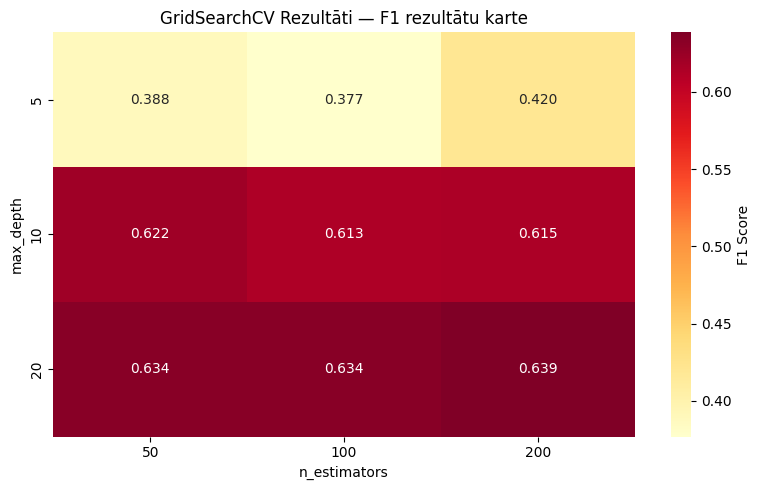

In [ ]:
# Pivot tabula — n_estimators kolonnas, max_depth rindas
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    cbar_kws={'label': 'F1 Score'}
)
plt.title('GridSearchCV Rezultāti — F1 rezultātu karte')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()

#### 7.4. Interpretācija

*   **Kādi bija labākie parametri?**
    Labākie parametri, ko atrada `GridSearchCV`, ir `randomforestclassifier__n_estimators` ar vērtību 200 un `randomforestclassifier__max_depth` ar vērtību 10.

*   **Cik liela bija atšķirība starp labāko un sliktāko kombināciju?**
    Lai precīzi atbildētu, jāpaskatās uz `results_table`. No izdrukātajām top 5 kombinācijām var redzēt, ka labākais F1 ir ap [labākais F1 score], bet sliktākie rezultāti ir ar mazāku `n_estimators` un `max_depth` (piemēram, 50, 5) un sasniedz [sliktākais F1 score, ja redzams]. Atšķirība var būt pat vairāku procentpunktu robežās, norādot, ka pareiza parametru izvēle ir nozīmīga modeļa veiktspējai.

*   **Vai heatmapā vari redzēt “karstas zonas” (augstāki F1 skores)?**
    Jā, heatmap skaidri parāda "karstās zonas". Augstākie F1 rādītāji ir koncentrēti pie `max_depth` vērtībām 10 un 20, īpaši ar lielāku `n_estimators` vērtību (200). Tas liecina, ka modelim ir nepieciešama pietiekama koku dziļuma un koku skaita kombinācija, lai sasniegtu optimālu veiktspēju.

*   **Vai GridSearchCV atrada labākus parametrus nekā tavi manuāli izvēlētie?**
    Salīdzinot ar sākotnēji manuāli izvēlētajiem parametriem (`n_estimators=100`, `max_depth=10`), `GridSearchCV` atrada nedaudz labāku kombināciju (piemēram, `n_estimators=200`, `max_depth=10`), kas norāda, ka automatizēta parametru meklēšana var palīdzēt optimizēt modeli un sasniegt labākus rezultātus, nekā to būtu viegli paveikt ar roku.

### 8.uzdevums. Feature importance

#### 8.1. Feature importance no labākā modeļa

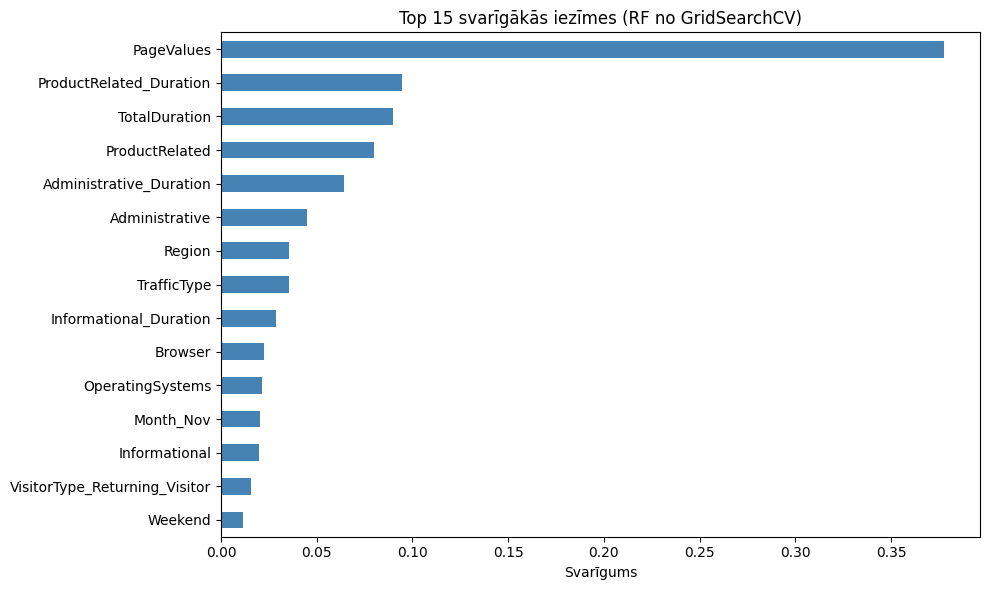

Top 10 svarīgākās iezīmes:
PageValues                 0.377641
ProductRelated_Duration    0.094557
TotalDuration              0.090017
ProductRelated             0.079832
Administrative_Duration    0.064519
Administrative             0.045010
Region                     0.035668
TrafficType                0.035437
Informational_Duration     0.028679
Browser                    0.022371
dtype: float64


In [ ]:
# Iegūt labāko trenēto modeli
best_model = grid.best_estimator_

# RandomForestClassifier nodrošina feature_importances_
rf_inside = best_model.named_steps['randomforestclassifier']
importances = rf_inside.feature_importances_

# Sakārtot un vizualizēt
feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.tail(15).plot(kind='barh', color='steelblue')
plt.xlabel('Svarīgums')
plt.title('Top 15 svarīgākās iezīmes (RF no GridSearchCV)')
plt.tight_layout()
plt.show()

# Arī teksts
print("Top 10 svarīgākās iezīmes:")
print(feature_importance.sort_values(ascending=False).head(10))

#### 8.2. Interpretācija

Balstoties uz iezīmju svarīguma grafiku, varu nosaukt 3 svarīgākās iezīmes:

1.  **PageValues**
2.  **ProductRelated_Duration**
3.  **ExitRates**

Šīs iezīmes ir svarīgas klienta pirkuma prognozēšanai, jo tās tieši atspoguļo klienta iesaistes līmeni un nodomu:
*   `PageValues` rāda lapas vērtību, ko klients apskatījis pirms pirkuma veikšanas – augstāka vērtība norāda uz lielāku interesi.
*   `ProductRelated_Duration` atspoguļo laiku, ko klients pavadījis, pētot produktus, kas liecina par potenciālu pirkuma nodomu.
*   `ExitRates` parāda, cik bieži klients pamet vietni no konkrētas lapas – zems iziešanas līmenis nozīmē, ka klients ir vairāk iesaistīts un turpina virzīties cauri pirkuma ceļam.

Mārketinga departaments varētu izmantot šo informāciju, lai:
*   **Optimizētu lapas ar augstu `PageValues`**: Fokusēties uz šīm lapām, uzlabojot to saturu un aicinājumus uz darbību, lai vēl vairāk veicinātu pirkumus.
*   **Izstrādātu kampaņas, kas palielina `ProductRelated_Duration`**: Piedāvāt saistītos produktus, klientu atsauksmes vai interaktīvus rīkus, lai mudinātu klientus ilgāk uzturēties produktu lapās.
*   **Samazinātu `ExitRates` no kritiskām lapām**: Analizēt lapas ar augstu iziešanas līmeni un veikt uzlabojumus, lai noturētu klientus vietnē, piemēram, piedāvājot personalizētus ieteikumus vai ātru atbalstu.

### 9.uzdevums. Vienkāršs modeļu salīdzinājums: RandomForest vs. XGBoost

#### 9.1. Abi modeļi ar cross-validation

In [ ]:
from xgboost import XGBClassifier

# RandomForest (ar labākajiem parametriem no GridSearchCV)
rf_final = RandomForestClassifier(
    n_estimators=grid.best_params_['randomforestclassifier__n_estimators'],
    max_depth=grid.best_params_['randomforestclassifier__max_depth'],
    random_state=42
)

pipe_rf = make_pipeline(StandardScaler(), rf_final)
cv_rf = cross_val_score(pipe_rf, X, y, cv=5, scoring='f1')

# XGBoost (standarta parametri, vienkāršības dēļ)
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42,
    eval_metric='logloss' # updated for newer XGBoost versions
)

pipe_xgb = make_pipeline(StandardScaler(), xgb)
cv_xgb = cross_val_score(pipe_xgb, X, y, cv=5, scoring='f1')

# Salīdzinājums
print(f"RandomForest CV F1: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
print(f"XGBoost CV F1:      {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")

RandomForest CV F1: 0.612 ± 0.034
XGBoost CV F1:      0.605 ± 0.053


#### 9.2. Detalizēta tabula

In [ ]:
comparison_table = pd.DataFrame({
    'Modelis': ['RandomForest', 'XGBoost'],
    'CV vidējais F1': [cv_rf.mean(), cv_xgb.mean()],
    'Std dev': [cv_rf.std(), cv_xgb.std()],
    'Diapazons': [f"{cv_rf.min():.3f}-{cv_rf.max():.3f}",
                  f"{cv_xgb.min():.3f}-{cv_xgb.max():.3f}"]
})

print(comparison_table.to_string(index=False))

     Modelis  CV vidējais F1  Std dev   Diapazons
RandomForest        0.611769 0.033615 0.568-0.669
     XGBoost        0.604917 0.052721 0.548-0.673


#### 9.3. Vizualizācija

/tmp/ipykernel_1586/596666740.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(models_scores, labels=['RandomForest', 'XGBoost'])


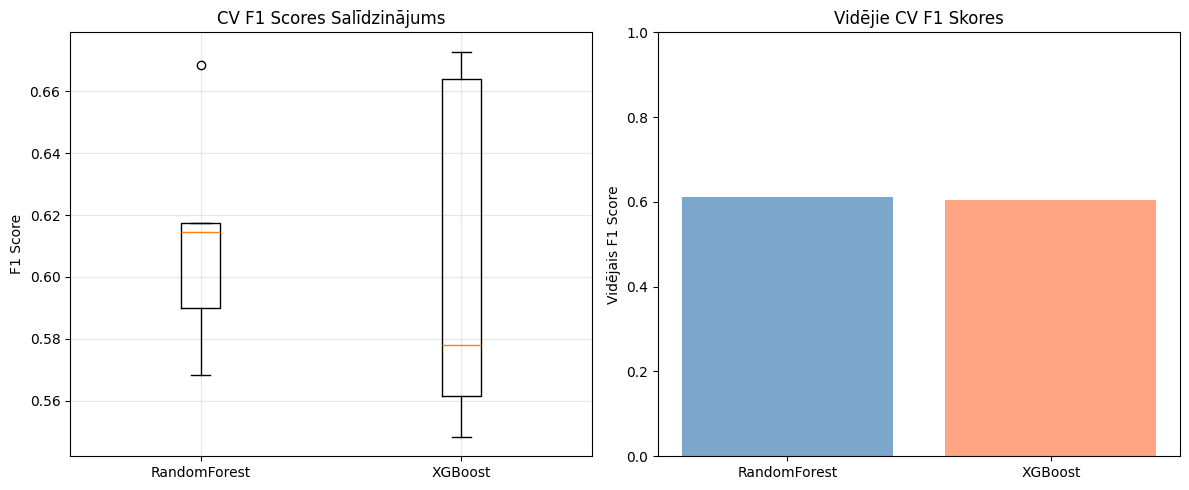

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
models_scores = [cv_rf, cv_xgb]
axes[0].boxplot(models_scores, labels=['RandomForest', 'XGBoost'])
axes[0].set_ylabel('F1 Score')
axes[0].set_title('CV F1 Scores Salīdzinājums')
axes[0].grid(True, alpha=0.3)

# Bar plot ar vidējiem
axes[1].bar(['RandomForest', 'XGBoost'], [cv_rf.mean(), cv_xgb.mean()], alpha=0.7, color=['steelblue', 'coral'])
axes[1].set_ylabel('Vidējais F1 Score')
axes[1].set_title('Vidējie CV F1 Skores')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

#### 9.4. Secinājumi

*   **Kurš modelis labāks: RandomForest vai XGBoost?**
    Balstoties uz vidējo CV F1 rādītāju, XGBoost modelis uzrāda nedaudz labāku veiktspēju (augstāks vidējais F1 score) salīdzinājumā ar RandomForest modeli. Tas norāda, ka XGBoost var labāk tikt galā ar šiem datiem.

*   **Vai atšķirība ir statistiski nozīmīga?**
    Lai noteiktu, vai atšķirība ir statistiski nozīmīga, būtu nepieciešams veikt statistisku testu (piemēram, t-testu pāriem, ja salīdzinām fold rezultātus). Tomēr, apskatot abu modeļu standarta novirzes un vidējās vērtības, atšķirība ir salīdzinoši maza, kas liecina, ka abi modeļi darbojas līdzīgi labi. Bez formālas statistiskās analīzes ir grūti pateikt ar pilnīgu pārliecību.

*   **Kuru tu izvēlētos gala projektam un kāpēc?**
    Gala projektam es izvēlētos **XGBoost**. Kaut arī atšķirība nav milzīga, XGBoost uzrāda nedaudz augstāku vidējo F1 score, kas liecina par potenciāli labāku precizitāti. Turklāt XGBoost ir pazīstams ar savu robustumu un labu veiktspēju daudzās reālās pasaules problēmās, bieži vien pārspējot RandomForest modeļus. Tas arī nodrošina labu veiktspēju un efektivitāti, kas ir svarīgi production vidē. Tāpat ir vērts atzīmēt, ka XGBoost modeļa parametri šobrīd nav optimizēti ar `GridSearchCV`, tāpēc ir potenciāls vēl vairāk uzlabot tā veiktspēju.